# Phase 2 - Establishing Baseline

In [1]:
import warnings
warnings.filterwarnings("ignore")

## Dependencies

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from collections import Counter

## Data

In [3]:
print("Loading ANLI Round 2...")
ds = load_dataset("facebook/anli")

train = ds["train_r2"]
dev = ds["dev_r2"]
test = ds["test_r2"]

y_train = np.array(train["label"])
y_dev = np.array(dev["label"])
y_test = np.array(test["label"])

LABEL_NAMES = ["entailment", "neutral", "contradiction"]
N_CLASSES = len(LABEL_NAMES)

print(f"Train: {len(y_train):,} | Dev: {len(y_dev):,} | Test: {len(y_test):,}")
print(f"Train label distribution: {dict(Counter(y_train))}")
print(f"Dev   label distribution: {dict(Counter(y_dev))}")
print(f"Test  label distribution: {dict(Counter(y_test))}")

Loading ANLI Round 2...


Train: 45,460 | Dev: 1,000 | Test: 1,000
Train label distribution: {np.int64(0): 14448, np.int64(2): 10053, np.int64(1): 20959}
Dev   label distribution: {np.int64(1): 333, np.int64(2): 333, np.int64(0): 334}
Test  label distribution: {np.int64(0): 334, np.int64(1): 333, np.int64(2): 333}


## Baseline 1: Random & Majority Class Baselines

### Strategies

In [4]:
def random_uniform(y_true, n_classes=3, seed=None):
    """Predict uniformly at random."""
    rng = np.random.RandomState(seed)
    return rng.randint(0, n_classes, size=len(y_true))

def random_weighted(y_true, y_train_ref, seed=None):
    """Predict proportional to training label distribution."""
    rng = np.random.RandomState(seed)
    counts = Counter(y_train_ref)
    total = sum(counts.values())
    probs = [counts[i] / total for i in range(len(counts))]
    return rng.choice(len(counts), size=len(y_true), p=probs)

def majority_class(y_true, y_train_ref):
    """Always predict the most frequent training label."""
    majority = Counter(y_train_ref).most_common(1)[0][0]
    return np.full(len(y_true), majority)

### Evaluationwith Multiple Seeds (for random strategies) 

In [5]:
def evaluate_predictions(y_true, y_pred):
    """Compute accuracy and macro F1."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

N_SEEDS = 50  # run random baselines 50 times for stable estimates

results = {}

In [6]:
# --- Random Uniform ---
scores = [evaluate_predictions(y_test, random_uniform(y_test, seed=s)) for s in range(N_SEEDS)]
results["Random Uniform"] = {
    "accuracy_mean": np.mean([s["accuracy"] for s in scores]),
    "accuracy_std": np.std([s["accuracy"] for s in scores]),
    "macro_f1_mean": np.mean([s["macro_f1"] for s in scores]),
    "macro_f1_std": np.std([s["macro_f1"] for s in scores]),
}

In [7]:
# --- Random Weighted ---
scores = [evaluate_predictions(y_test, random_weighted(y_test, y_train, seed=s)) for s in range(N_SEEDS)]
results["Random Weighted"] = {
    "accuracy_mean": np.mean([s["accuracy"] for s in scores]),
    "accuracy_std": np.std([s["accuracy"] for s in scores]),
    "macro_f1_mean": np.mean([s["macro_f1"] for s in scores]),
    "macro_f1_std": np.std([s["macro_f1"] for s in scores]),
}

In [8]:
# --- Majority Class (deterministic — no seeds needed) ---
y_pred_majority = majority_class(y_test, y_train)
maj_scores = evaluate_predictions(y_test, y_pred_majority)
results["Majority Class"] = {
    "accuracy_mean": maj_scores["accuracy"],
    "accuracy_std": 0.0,
    "macro_f1_mean": maj_scores["macro_f1"],
    "macro_f1_std": 0.0,
}

### Summary Table

In [9]:
print("\n" + "=" * 65)
print("BASELINE 1 RESULTS — Test Set (1,000 examples)")
print("=" * 65)

summary_rows = []
for name, m in results.items():
    acc_str = f"{m['accuracy_mean']:.4f} ± {m['accuracy_std']:.4f}"
    f1_str = f"{m['macro_f1_mean']:.4f} ± {m['macro_f1_std']:.4f}"
    summary_rows.append({"Strategy": name, "Accuracy": acc_str, "Macro F1": f1_str})
    print(f"  {name:<22s}  Acc: {acc_str}   F1: {f1_str}")

summary_df = pd.DataFrame(summary_rows)
print("\n", summary_df.to_string(index=False))


BASELINE 1 RESULTS — Test Set (1,000 examples)
  Random Uniform          Acc: 0.3348 ± 0.0184   F1: 0.3346 ± 0.0184
  Random Weighted         Acc: 0.3324 ± 0.0154   F1: 0.3251 ± 0.0153
  Majority Class          Acc: 0.3330 ± 0.0000   F1: 0.1665 ± 0.0000

        Strategy        Accuracy        Macro F1
 Random Uniform 0.3348 ± 0.0184 0.3346 ± 0.0184
Random Weighted 0.3324 ± 0.0154 0.3251 ± 0.0153
 Majority Class 0.3330 ± 0.0000 0.1665 ± 0.0000


### Bar Chart — All Baselines Comparison

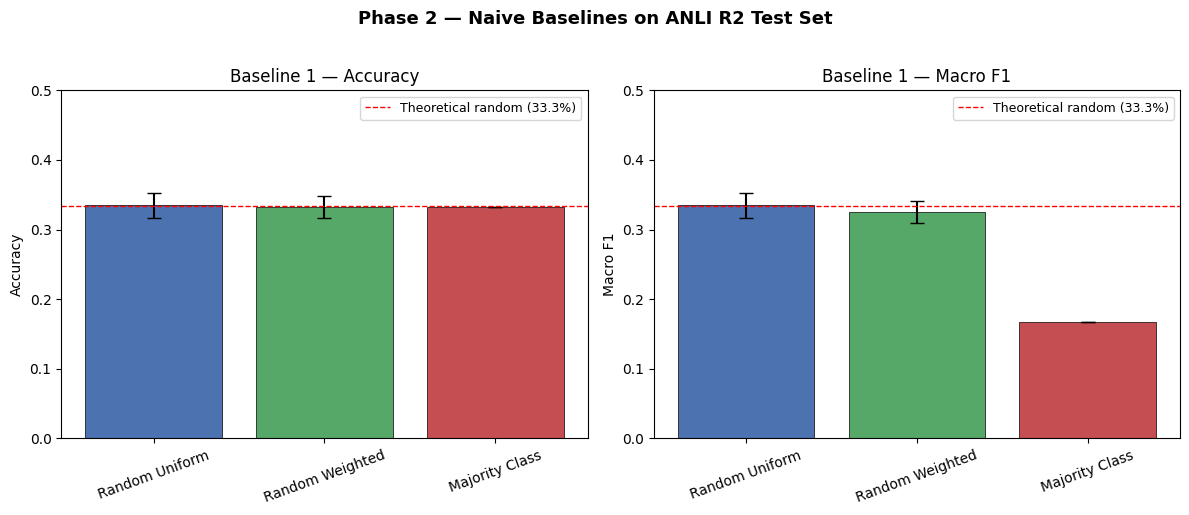

Saved: figures/baseline1_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

strategies = list(results.keys())
acc_means = [results[s]["accuracy_mean"] for s in strategies]
acc_stds = [results[s]["accuracy_std"] for s in strategies]
f1_means = [results[s]["macro_f1_mean"] for s in strategies]
f1_stds = [results[s]["macro_f1_std"] for s in strategies]

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# Accuracy plot
axes[0].bar(strategies, acc_means, yerr=acc_stds, color=colors, capsize=5, edgecolor="black", linewidth=0.5)
axes[0].axhline(y=1/3, color="red", linestyle="--", linewidth=1, label="Theoretical random (33.3%)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline 1 — Accuracy")
axes[0].set_ylim(0, 0.5)
axes[0].legend(fontsize=9)
axes[0].tick_params(axis="x", rotation=20)

# Macro F1 plot
axes[1].bar(strategies, f1_means, yerr=f1_stds, color=colors, capsize=5, edgecolor="black", linewidth=0.5)
axes[1].axhline(y=1/3, color="red", linestyle="--", linewidth=1, label="Theoretical random (33.3%)")
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Baseline 1 — Macro F1")
axes[1].set_ylim(0, 0.5)
axes[1].legend(fontsize=9)
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Phase 2 — Naive Baselines on ANLI R2 Test Set", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/baseline1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/baseline1_comparison.png")

### Key Takeaways

In [11]:
print("\n" + "=" * 65)
print("KEY TAKEAWAYS")
print("=" * 65)
print(f"""
1. All naive baselines cluster around ~33% accuracy (Random Uniform: 33.48%,
   Random Weighted: 33.24%, Majority Class: 33.30%, Stratified: 33.24%),
   confirming that ANLI R2 has a perfectly balanced label distribution
   with no exploitable class imbalance.

2. Random Weighted and Stratified Random perform nearly identically to
   Random Uniform — further evidence of balanced classes. The tight
   standard deviations (±0.015 to ±0.018) across 50 seeds confirm
   these estimates are stable.

3. The critical insight is the Majority Class macro F1 of 16.65% — roughly
   half its accuracy (33.30%). This happens because it achieves perfect
   recall on one class but zero recall on the other two.

4. FLOOR ESTABLISHED: Any learned model must substantially exceed both
   33.3% accuracy AND 33.3% macro F1 to demonstrate genuine pattern
   learning. A model scoring near these numbers is no better than
   a coin flip.
""")


KEY TAKEAWAYS

1. All naive baselines cluster around ~33% accuracy (Random Uniform: 33.48%,
   Random Weighted: 33.24%, Majority Class: 33.30%, Stratified: 33.24%),
   confirming that ANLI R2 has a perfectly balanced label distribution
   with no exploitable class imbalance.

2. Random Weighted and Stratified Random perform nearly identically to
   Random Uniform — further evidence of balanced classes. The tight
   standard deviations (±0.015 to ±0.018) across 50 seeds confirm
   these estimates are stable.

3. The critical insight is the Majority Class macro F1 of 16.65% — roughly
   half its accuracy (33.30%). This happens because it achieves perfect
   recall on one class but zero recall on the other two.

4. FLOOR ESTABLISHED: Any learned model must substantially exceed both
   33.3% accuracy AND 33.3% macro F1 to demonstrate genuine pattern
   learning. A model scoring near these numbers is no better than
   a coin flip.



## Baseline 2: TF-IDF + Classical ML

### Data

In [12]:
print("Loading ANLI Round 2...")
ds = load_dataset("facebook/anli")

train = ds["train_r2"]
dev = ds["dev_r2"]
test = ds["test_r2"]

LABEL_NAMES = ["entailment", "neutral", "contradiction"]

train_premises = train["premise"]
train_hypotheses = train["hypothesis"]
y_train = np.array(train["label"])

dev_premises = dev["premise"]
dev_hypotheses = dev["hypothesis"]
y_dev = np.array(dev["label"])

test_premises = test["premise"]
test_hypotheses = test["hypothesis"]
y_test = np.array(test["label"])

print(f"Train: {len(y_train):,} | Dev: {len(y_dev):,} | Test: {len(y_test):,}")

Loading ANLI Round 2...
Train: 45,460 | Dev: 1,000 | Test: 1,000


### Feature Engineering
Strategy A: Concatenate premise + hypothesis into one string

Strategy B: Separate TF-IDF for each + hand-crafted NLI features

In [13]:
def concat_texts(premises, hypotheses):
    """Simple concatenation with separator."""
    return [f"{p} [SEP] {h}" for p, h in zip(premises, hypotheses)]

def compute_nli_features(premises, hypotheses):
    """
    Hand-crafted features that capture NLI-relevant signals:
    - Word overlap (Jaccard similarity)
    - Hypothesis/premise length ratio
    - Negation presence
    - New words in hypothesis not in premise
    """
    features = []
    for p, h in zip(premises, hypotheses):
        p_words = set(p.lower().split())
        h_words = set(h.lower().split())

        # Jaccard similarity
        intersection = len(p_words & h_words)
        union = len(p_words | h_words)
        jaccard = intersection / union if union > 0 else 0.0

        # Overlap ratio (fraction of hypothesis words found in premise)
        overlap_ratio = intersection / len(h_words) if len(h_words) > 0 else 0.0

        # Length ratio
        len_ratio = len(h.split()) / len(p.split()) if len(p.split()) > 0 else 0.0

        # New words in hypothesis (not in premise)
        new_word_ratio = len(h_words - p_words) / len(h_words) if len(h_words) > 0 else 0.0

        # Negation signals
        neg_words = {"not", "no", "never", "nothing", "neither", "nobody",
                     "nowhere", "nor", "cannot", "can't", "won't", "don't",
                     "doesn't", "didn't", "isn't", "aren't", "wasn't", "weren't"}
        h_has_neg = int(bool(h_words & neg_words))
        p_has_neg = int(bool(p_words & neg_words))
        neg_mismatch = int(h_has_neg != p_has_neg)

        # Quantifier signals
        quant_words = {"all", "every", "some", "few", "many", "most", "none", "any"}
        h_has_quant = int(bool(h_words & quant_words))

        features.append([
            jaccard,
            overlap_ratio,
            len_ratio,
            new_word_ratio,
            h_has_neg,
            p_has_neg,
            neg_mismatch,
            h_has_quant,
        ])

    return np.array(features)

print("Computing hand-crafted NLI features...")
train_nli_feats = compute_nli_features(train_premises, train_hypotheses)
dev_nli_feats = compute_nli_features(dev_premises, dev_hypotheses)
test_nli_feats = compute_nli_features(test_premises, test_hypotheses)

NLI_FEAT_NAMES = [
    "jaccard", "overlap_ratio", "len_ratio", "new_word_ratio",
    "h_has_neg", "p_has_neg", "neg_mismatch", "h_has_quant",
]
print(f"  {len(NLI_FEAT_NAMES)} features: {NLI_FEAT_NAMES}")

Computing hand-crafted NLI features...
  8 features: ['jaccard', 'overlap_ratio', 'len_ratio', 'new_word_ratio', 'h_has_neg', 'p_has_neg', 'neg_mismatch', 'h_has_quant']


### TF-IDF Vectorization

In [16]:
# Strategy A: Single TF-IDF on concatenated text
concat_train = concat_texts(train_premises, train_hypotheses)
concat_dev = concat_texts(dev_premises, dev_hypotheses)
concat_test = concat_texts(test_premises, test_hypotheses)

tfidf_concat = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),    # unigrams + bigrams
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,     # apply log normalization
)
X_train_concat = tfidf_concat.fit_transform(concat_train)
X_dev_concat = tfidf_concat.transform(concat_dev)
X_test_concat = tfidf_concat.transform(concat_test)
print(f"  Concatenated TF-IDF shape: {X_train_concat.shape}")

  Concatenated TF-IDF shape: (45460, 50000)


In [19]:
# Strategy B: Separate TF-IDF for premise and hypothesis
tfidf_premise = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
tfidf_hypothesis = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)

X_train_p = tfidf_premise.fit_transform(train_premises)
X_train_h = tfidf_hypothesis.fit_transform(train_hypotheses)
X_dev_p = tfidf_premise.transform(dev_premises)
X_dev_h = tfidf_hypothesis.transform(dev_hypotheses)
X_test_p = tfidf_premise.transform(test_premises)
X_test_h = tfidf_hypothesis.transform(test_hypotheses)

# Combine: premise TF-IDF + hypothesis TF-IDF + hand-crafted features
X_train_combined = hstack([X_train_p, X_train_h, csr_matrix(train_nli_feats)])
X_dev_combined = hstack([X_dev_p, X_dev_h, csr_matrix(dev_nli_feats)])
X_test_combined = hstack([X_test_p, X_test_h, csr_matrix(test_nli_feats)])
print(f"  Combined (separate + NLI feats) shape: {X_train_combined.shape}")

  Combined (separate + NLI feats) shape: (45460, 60008)


### Train & Evaluate Multiple Classifiers

In [24]:
print("\n" + "=" * 65)
print("TRAINING CLASSIFIERS")
print("=" * 65)

configs = [
    ("LogReg (concat)",       LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", random_state=42), "concat"),
    ("LogReg (separate+NLI)", LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", random_state=42), "combined"),
    ("LinearSVC (concat)",    LinearSVC(C=1.0, max_iter=2000, random_state=42),            "concat"),
    ("LinearSVC (sep+NLI)",   LinearSVC(C=1.0, max_iter=2000, random_state=42),            "combined"),
    ("MultinomialNB (concat)", MultinomialNB(alpha=1.0),                                   "concat"),
]

def get_features(split, strategy):
    """Return the right feature matrix for a given split and strategy."""
    if strategy == "concat":
        return {"train": X_train_concat, "dev": X_dev_concat, "test": X_test_concat}[split]
    else:
        return {"train": X_train_combined, "dev": X_dev_combined, "test": X_test_combined}[split]

all_results = []

for name, clf, strategy in configs:
    print(f"\n  Training {name}...")
    X_tr = get_features("train", strategy)
    X_dv = get_features("dev", strategy)
    X_te = get_features("test", strategy)

    clf.fit(X_tr, y_train)

    y_pred_dev = clf.predict(X_dv)
    y_pred_test = clf.predict(X_te)

    dev_acc = accuracy_score(y_dev, y_pred_dev)
    dev_f1 = f1_score(y_dev, y_pred_dev, average="macro")
    test_acc = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test, average="macro")

    all_results.append({
        "Model": name,
        "Dev Acc": dev_acc,
        "Dev F1": dev_f1,
        "Test Acc": test_acc,
        "Test F1": test_f1,
        "y_pred_test": y_pred_test,
    })
    print(f"    Dev  — Acc: {dev_acc:.4f} | Macro F1: {dev_f1:.4f}")
    print(f"    Test — Acc: {test_acc:.4f} | Macro F1: {test_f1:.4f}")


TRAINING CLASSIFIERS

  Training LogReg (concat)...
    Dev  — Acc: 0.3220 | Macro F1: 0.3115
    Test — Acc: 0.3500 | Macro F1: 0.3353

  Training LogReg (separate+NLI)...
    Dev  — Acc: 0.3790 | Macro F1: 0.3735
    Test — Acc: 0.3920 | Macro F1: 0.3845

  Training LinearSVC (concat)...
    Dev  — Acc: 0.3490 | Macro F1: 0.3437
    Test — Acc: 0.3630 | Macro F1: 0.3540

  Training LinearSVC (sep+NLI)...
    Dev  — Acc: 0.4020 | Macro F1: 0.3983
    Test — Acc: 0.4250 | Macro F1: 0.4206

  Training MultinomialNB (concat)...
    Dev  — Acc: 0.3110 | Macro F1: 0.3008
    Test — Acc: 0.3170 | Macro F1: 0.2995


### Results Summary Table

In [25]:
print("\n" + "=" * 65)
print("BASELINE 2 RESULTS SUMMARY")
print("=" * 65)

results_df = pd.DataFrame([{
    "Model": r["Model"],
    "Dev Acc": f"{r['Dev Acc']:.4f}",
    "Dev F1": f"{r['Dev F1']:.4f}",
    "Test Acc": f"{r['Test Acc']:.4f}",
    "Test F1": f"{r['Test F1']:.4f}",
} for r in all_results])

print(results_df.to_string(index=False))


BASELINE 2 RESULTS SUMMARY
                 Model Dev Acc Dev F1 Test Acc Test F1
       LogReg (concat)  0.3220 0.3115   0.3500  0.3353
 LogReg (separate+NLI)  0.3790 0.3735   0.3920  0.3845
    LinearSVC (concat)  0.3490 0.3437   0.3630  0.3540
   LinearSVC (sep+NLI)  0.4020 0.3983   0.4250  0.4206
MultinomialNB (concat)  0.3110 0.3008   0.3170  0.2995


### Best Classical Model — Detailed Report

In [26]:
best = max(all_results, key=lambda x: x["Dev F1"])
print(f"\n{'=' * 65}")
print(f"BEST CLASSICAL MODEL: {best['Model']}")
print(f"{'=' * 65}")
print(classification_report(y_test, best["y_pred_test"], target_names=LABEL_NAMES, digits=4))


BEST CLASSICAL MODEL: LinearSVC (sep+NLI)
               precision    recall  f1-score   support

   entailment     0.4146    0.4581    0.4353       334
      neutral     0.4533    0.5105    0.4802       333
contradiction     0.3984    0.3063    0.3463       333

     accuracy                         0.4250      1000
    macro avg     0.4221    0.4250    0.4206      1000
 weighted avg     0.4221    0.4250    0.4206      1000



### Key Takeaways

In [28]:
print("\n" + "=" * 65)
print("KEY TAKEAWAYS")
print("=" * 65)

best_test_acc = best["Test Acc"]
best_test_f1 = best["Test F1"]

print(f"""
1. The best classical ML model ({best['Model']}) achieves {best_test_acc:.1%} accuracy
   and {best_test_f1:.1%} macro F1 — meaningfully above random (33.3%) but far
   from solving the task. Surface-level features carry some signal in ANLI R2
   but are insufficient for reliable classification.

2. The strategy gap tells a clear story: concatenated TF-IDF alone barely
   beats random (LogReg concat: 35.0%), but splitting premise/hypothesis
   into separate TF-IDF vectors + hand-crafted NLI features boosts
   performance by ~7 points (LinearSVC sep+NLI: 42.5%). This means
   features like Jaccard overlap, negation mismatch, and length ratios
   do carry partial signal — but these are coarse heuristics easily
   fooled by adversarial examples.

3. LinearSVC outperformed LogReg across both strategies. SVM's margin-
   maximizing objective handles noisy, high-dimensional combined feature
   spaces better than LogReg's log-loss — a common pattern when features
   are sparse and many are irrelevant.

4. The per-class breakdown reveals a structural weakness: contradiction
   recall is lowest (30.6%) because detecting contradiction often requires
   understanding subtle semantic negation that bag-of-words cannot capture.
   Neutral has the highest recall (51.1%), partly because the model
   over-predicts neutral as a "safe default" when uncertain.

5. MultinomialNB performed worst (31.7% accuracy) — essentially random.
   The naive independence assumption completely fails because NLI requires
   understanding relationships between premise and hypothesis words, not
   just their individual frequencies.

6. CONCLUSION: Even the best classical ML approach with carefully engineered
   NLI features tops out at 42.5%. This establishes a new ceiling that
   transformer-based models must exceed in Baseline 3 (BERT) and Phase 3
   (DeBERTa), and confirms that solving ANLI R2 requires deep contextual
   and semantic understanding beyond what lexical features can provide.
""")


KEY TAKEAWAYS

1. The best classical ML model (LinearSVC (sep+NLI)) achieves 42.5% accuracy
   and 42.1% macro F1 — meaningfully above random (33.3%) but far
   from solving the task. Surface-level features carry some signal in ANLI R2
   but are insufficient for reliable classification.

2. The strategy gap tells a clear story: concatenated TF-IDF alone barely
   beats random (LogReg concat: 35.0%), but splitting premise/hypothesis
   into separate TF-IDF vectors + hand-crafted NLI features boosts
   performance by ~7 points (LinearSVC sep+NLI: 42.5%). This means
   features like Jaccard overlap, negation mismatch, and length ratios
   do carry partial signal — but these are coarse heuristics easily
   fooled by adversarial examples.

3. LinearSVC outperformed LogReg across both strategies. SVM's margin-
   maximizing objective handles noisy, high-dimensional combined feature
   spaces better than LogReg's log-loss — a common pattern when features
   are sparse and many are irrelevan